In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.models import * 
from tensorflow.keras.preprocessing import image

In [3]:
train_datagen = image.ImageDataGenerator(
    rotation_range=15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    width_shift_range=0.1,
    height_shift_range=0.1
)
test_datagen= image.ImageDataGenerator(rotation_range=15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    width_shift_range=0.1,
    height_shift_range=0.1)

In [5]:
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Final Project/Dataset_1/train',
    target_size = (224,224),
    batch_size = 8,
    class_mode = 'categorical')
test_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Final Project/Dataset_1/test',
    target_size = (224,224),
    batch_size = 8,
    class_mode = 'categorical')
validation_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Final Project/Dataset_1/valid',
    target_size = (224,224),
    batch_size = 8,
    shuffle=True,
    class_mode = 'categorical')

Found 620 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Found 91 images belonging to 4 classes.


In [ ]:
base_model = tf.keras.applications.ResNet152(weights='imagenet', input_shape=(224,224,3), include_top=False)

for layer in base_model.layers:
    layer.trainable=True
model = Sequential()
model.add(base_model)
model.add(GaussianNoise(0.25))
model.add(GlobalAveragePooling2D())
model.add(Dense(1024,activation='relu'))
model.add(BatchNormalization())
model.add(GaussianNoise(0.25))
model.add(Dropout(0.25))
model.add(Dense(4, activation='sigmoid'))
model.summary()

234698864/234698864 [==============================] - 12s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet152 (Functional)      (None, 7, 7, 2048)        58370944  
                                                                 
 gaussian_noise (GaussianNoi  (None, 7, 7, 2048)       0         
 se)                                                             
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 1024)              2098176   
                                                                 
 batch_normalization (BatchN  (None, 1024)             4096      
 ormalization)                                        

In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
              metrics=['accuracy','AUC','Precision','Recall'])

In [ ]:
from keras.callbacks import EarlyStopping
es=EarlyStopping(monitor='val_loss',patience=3)
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=validation_generator,
    steps_per_epoch= 75
    )

Epoch 1/100
75/75 [==============================] - 316s 4s/step - loss: 1.5608 - accuracy: 0.4121 - auc: 0.6464 - precision: 0.3291 - recall: 0.6449 - val_loss: 1.4529 - val_accuracy: 0.3516 - val_auc: 0.6211 - val_precision: 0.3228 - val_recall: 0.5604
Epoch 2/100
75/75 [==============================] - 24s 320ms/step - loss: 1.1165 - accuracy: 0.5846 - auc: 0.7828 - precision: 0.4112 - recall: 0.7638 - val_loss: 1.4339 - val_accuracy: 0.3736 - val_auc: 0.6318 - val_precision: 0.2951 - val_recall: 0.5934
Epoch 3/100
75/75 [==============================] - 22s 286ms/step - loss: 0.9404 - accuracy: 0.6566 - auc: 0.8241 - precision: 0.4345 - recall: 0.8057 - val_loss: 1.5702 - val_accuracy: 0.3956 - val_auc: 0.6262 - val_precision: 0.3059 - val_recall: 0.7363
Epoch 4/100
75/75 [==============================] - 21s 283ms/step - loss: 0.7752 - accuracy: 0.7035 - auc: 0.8614 - precision: 0.4450 - recall: 0.8476 - val_loss: 1.7807 - val_accuracy: 0.2637 - val_auc: 0.6128 - val_precision

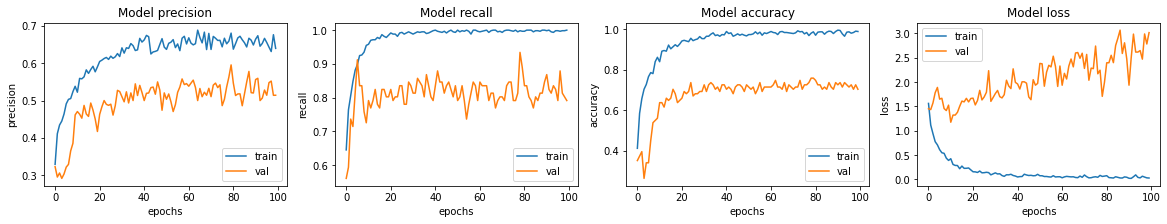

In [ ]:
fig,ax=plt.subplots(1,4,figsize=(20,3))
ax=ax.ravel()
for i,met in enumerate(['precision','recall','accuracy','loss']):
  ax[i].plot(history.history[met])
  ax[i].plot(history.history['val_'+met])
  ax[i].set_title('Model {}'.format(met))
  ax[i].set_xlabel('epochs')
  ax[i].set_ylabel(met)
  ax[i].legend(['train', 'val'])

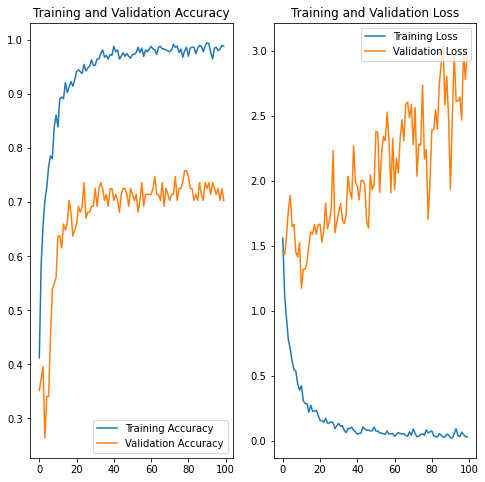

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(100)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
model.evaluate(train_generator)

77/77 [==============================] - 11s 148ms/step - loss: 0.0061 - accuracy: 0.9984 - auc: 0.9986 - precision: 0.7711 - recall: 1.0000


[0.0060591851361095905,
 0.9983686804771423,
 0.9985730648040771,
 0.7710691690444946,
 1.0]

In [ ]:
model.evaluate(test_generator)

40/40 [==============================] - 6s 149ms/step - loss: 0.2741 - accuracy: 0.9619 - auc: 0.9846 - precision: 0.6865 - recall: 0.9873


[0.27414458990097046,
 0.961904764175415,
 0.9845855832099915,
 0.6865342259407043,
 0.9873015880584717]

In [ ]:
model.evaluate(validation_generator)

12/12 [==============================] - 2s 134ms/step - loss: 3.0188 - accuracy: 0.7253 - auc: 0.8329 - precision: 0.4863 - recall: 0.7802


[3.0187904834747314,
 0.7252747416496277,
 0.8328704237937927,
 0.48630136251449585,
 0.7802197933197021]

In [6]:
model.save('content/drive/MyDrive/Colab Notebooks/Final Project/Original 5 Models/ResNet.h5',model)

NameError: ignored

In [8]:
mymodel=load_model('content/drive/MyDrive/Colab Notebooks/Final Project/Original 5 Models/ResNet.h5')

In [ ]:
mymodel.evaluate(train_generator)

77/77 [==============================] - 14s 147ms/step - loss: 0.0135 - accuracy: 0.9967 - auc: 0.9981 - precision: 0.7779 - recall: 1.0000


[0.013507513329386711,
 0.9967373609542847,
 0.9981189966201782,
 0.7779187560081482,
 1.0]

In [ ]:
mymodel.evaluate(test_generator)

40/40 [==============================] - 6s 144ms/step - loss: 0.3208 - accuracy: 0.9587 - auc: 0.9839 - precision: 0.6732 - recall: 0.9810


[0.32080769538879395,
 0.958730161190033,
 0.983875036239624,
 0.673202633857727,
 0.9809523820877075]

In [ ]:
mymodel.evaluate(validation_generator)

12/12 [==============================] - 2s 133ms/step - loss: 3.1889 - accuracy: 0.7143 - auc: 0.8312 - precision: 0.5252 - recall: 0.8022


[3.1889171600341797,
 0.7142857313156128,
 0.8311798572540283,
 0.5251798629760742,
 0.8021978139877319]

1/1 [==============================] - 0s 34ms/step
[[1.6535861e-04 2.1244949e-03 5.6799300e-02 9.9994051e-01]]
THE UPLOADED IMAGE IS SUSPECTED AS: squamous cell carcinoma


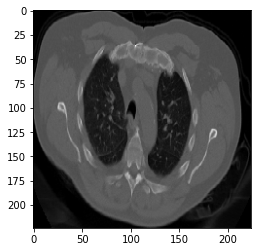

In [ ]:
from keras.preprocessing import image
img = tf.keras.utils.load_img('/content/drive/MyDrive/Colab Notebooks/Final Project/1.jpg',target_size=(224,224))
imag = tf.keras.utils.img_to_array(img)
imaga = np.expand_dims(imag,axis=0) 
ypred = model.predict(imaga)
print(ypred)
a=np.argmax(ypred,-1)
if a==0:
  op="Adenocarcinoma"
elif a==1:
  op="large cell carcinoma"
elif a==2:
  op="normal (void of cancer)"
else:
  op="squamous cell carcinoma"    
plt.imshow(img)
print("THE UPLOADED IMAGE IS SUSPECTED AS: "+str(op))  
